## The RAG Pipeline



#### Quick Read
In early 2024, a Series B startup in the legal tech space built a RAG system to help lawyers search
through case law. They indexed 10,000 legal documents, built a beautiful search interface, and demoed it
to their first enterprise customer.

The demo went like this: The lawyer typed "What are the precedents for wrongful termination in
California?" The system returned five passages. Every passage was garbled nonsense – fragments of
sentences, cut-off citations, and chunks that started mid-paragraph with no context.

The cause was invisible and devastating. The engineering team had used OpenAI's
*text-embedding-ada-002* model to generate embeddings at indexing time. But at query time, a
configuration error meant the system was using *text-embedding-3-small* to embed the search query.

Two different embedding models. Two different vector spaces. The cosine similarity between a query
vector and a document vector was essentially random noise.

The vectors were 1,536 dimensions (ada-002) vs. 1,536 dimensions (text-embedding-3-small). Same
dimensionality. No error was thrown. No test failed. The system looked healthy by every metric except
the one that mattered: the results were meaningless.


The startup lost the deal. The engineer who caused the mismatch had left the company two weeks earlier,
and nobody else knew which embedding model had been used during indexing. There was no
documentation, no metadata, no version tracking.

This is a pipeline failure.  
Not a model failure,  
not an infrastructure failure,  
not a prompt failure.  
A
mismatch between two stages of a five-stage process that nobody was monitoring end-to-end.

Every RAG system, from a weekend prototype to a production system serving millions of queries,
follows the same five-stage pipeline:
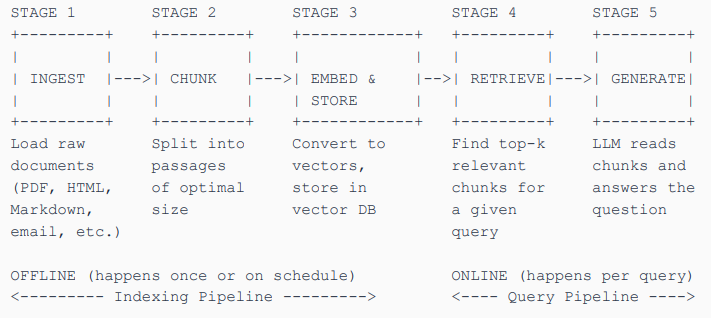

### Stage 1: Ingestion – loading raw documents
Ingestion is the process of converting raw documents into clean text that the rest of the pipeline can
process  

Each format requires a different parser. Each parser has edge cases.


### Stage 2: Chunking – splitting documents into passages
Once you have clean text, you need to split it into chunks – passages that are small enough to be relevant
to a specific question but large enough to contain meaningful context.  

Common chunking strategies:

• Fixed-size: Split every N tokens with M-token overlap. Simple but can cut mid-sentence.

• Recursive: Split by paragraph, then by sentence if paragraphs are too long. Respects natural
boundaries.

• Semantic: Use an LLM or embedding model to detect topic shifts and split at topic boundaries.
Best quality but most expensive.

• Document-structure: Split by headings, sections, or HTML tags. Works well for structured
documents.

### Stage 3: Embedding and storage – turning text into vectors
Each chunk gets converted into a vector – a list of numbers (typically 768 to 3,072 numbers) that
represents the meaning of the text in a mathematical space.

These vectors have a remarkable property: text with similar meaning produces vectors that are close
together in this high-dimensional space.

 The vectors are stored in a vector database (Pinecone, Weaviate, Chroma, etc.) that is optimized for
finding the nearest neighbors quickly.

### Stage 4: Retrieval – finding relevant chunks
When a user asks a question, the query goes through the same embedding model to produce a query
vector. Then the vector database finds the top-k most similar document vectors.

 Retrieval parameters:

• top-k: How many chunks to return (typically 3-10).

• similarity threshold: Minimum similarity score to include (e.g., 0.7).

• metadata filters: Narrow search to specific documents, date ranges, or categories.

This stage must be fast – under 100ms for a good user experience. Vector databases achieve this speed
using approximate nearest neighbor (ANN) algorithms like HNSW

### Stage 5: Generation – the LLM produces an answer
The retrieved chunks are assembled into a prompt with the user's question, and the LLM generates an
answer.  

Key design decisions at this stage:

• System prompt: How strict should the model be about staying in context?

• Max tokens: How long can the answer be?

• Temperature: 0.0 for factual answers, higher for creative responses.

• Citation format: Inline references or footnotes?



### Production considerations
1. Pipeline versioning. Every component of the pipeline should be versioned:
2. Re-indexing strategy. When the embedding model changes, all existing vectors become invalid. Plan
for this.
3. Health monitoring. Check pipeline health automatically.

###Prompt caching — the overlooked cost lever
In a RAG pipeline, the same system prompt and often the same retrieved chunks appear in hundreds of
queries.


### When caching applies in RAG:
1. System prompt: Cache your system prompt — it's identical across every query. This is free
money.
2. Static context: If you include static documents (company policy, product catalog) in every
prompt, cache them.
3. Retrieved chunks (partial): If your top-k chunks overlap significantly across queries (common
for narrow domains), caching helps.


# Key Takeaways

1. **RAG is a five-stage pipeline.**
   The stages are:

   * Ingestion
   * Chunking
   * Embedding & Storage
   * Retrieval
   * Generation

   Each stage has its own failure modes.

2. **Stages 1–3 are offline; stages 4–5 are online.**
   Optimize offline stages for **quality**. Optimize online stages for **latency and cost**.

3. **The embedding model must match between indexing and querying.**
   This is the single most common and most devastating RAG bug. Log the model name with every vector.

4. **Generation is the latency bottleneck.**
   Typically, **80–95% of online latency** comes from generation. Optimize by:

   * Streaming responses.
   * Reducing context size.
   * Using a faster model.

5. **Query cost is constant regardless of corpus size.**
   Whether you have 1,000 or 1,000,000 documents, you always retrieve the same `top-k` chunks. This is RAG's scaling advantage.

6. **Pipeline versioning is not optional.**
   Log the version of every component:

   * Parser
   * Chunker
   * Embedding model
   * Generation model

   When something breaks, you need to know what changed.

7. **Silent failures are the norm.**
   RAG pipelines rarely crash. They degrade silently. Build monitoring that checks **retrieval relevance and answer accuracy**, not just uptime.

8. **Start with NumPy, then migrate to a vector database.**
   For prototyping, in-memory search is fast and free. Migrate to **Pinecone** when you exceed ~10K chunks or need persistence.

9. **Chunk quality determines everything downstream.**
   Bad chunks produce bad embeddings, bad retrieval, and bad answers. Invest time in your chunking strategy early.

10. **Measure each stage independently.**
    If answer quality drops, you need to know whether the problem is:

    * **Retrieval:** Wrong chunks were found.
    * **Generation:** The right chunks were found, but the answer was wrong.

    Stage-level metrics make debugging possible.
